In [74]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

os.makedirs("images", exist_ok=True)
df = pd.read_csv( '../data/pokemon.csv' )

df.head()

,id,name,height,weight,primary_type,hp,attack,defense,special_attack,special_defense,speed
0,1,bulbasaur,7,69,grass,45,49,49,65,65,45
1,2,ivysaur,10,130,grass,60,62,63,80,80,60
2,3,venusaur,20,1000,grass,80,82,83,100,100,80
3,4,charmander,6,85,fire,39,52,43,60,50,65
4,5,charmeleon,11,190,fire,58,64,58,80,65,80


In [75]:
df.shape

(1024, 11)

In [76]:
df.describe()

,id,height,weight,hp,attack,defense,special_attack,special_defense,speed
count,1024.00000,1024.000000,1024.000000,1024.000000,1024.000000,1024.000000,1024.000000,1024.000000,1024.000000
mean,512.50000,12.125000,670.516602,70.166992,77.511719,72.421875,70.063477,70.188477,67.166016
std,295.74764,12.484516,1213.144397,26.638238,29.795291,29.173190,29.667576,26.646534,28.723881
min,1.00000,1.000000,1.000000,1.000000,5.000000,5.000000,10.000000,20.000000,5.000000
25%,256.75000,5.000000,85.000000,50.000000,55.000000,50.000000,47.000000,50.000000,45.000000
50%,512.50000,10.000000,280.000000,68.000000,75.000000,70.000000,65.000000,66.500000,65.000000
75%,768.25000,15.000000,701.250000,85.000000,100.000000,90.000000,90.000000,85.250000,88.250000
max,1024.00000,200.000000,9999.000000,255.000000,181.000000,230.000000,173.000000,230.000000,200.000000


In [77]:
df["primary_type"].value_counts()

primary_type
water       134
normal      118
grass       103
bug          83
fire         66
psychic      60
electric     59
rock         58
dark         45
poison       41
ground       40
fighting     40
dragon       37
steel        36
ghost        35
ice          31
fairy        29
flying        9
Name: count, dtype: int64

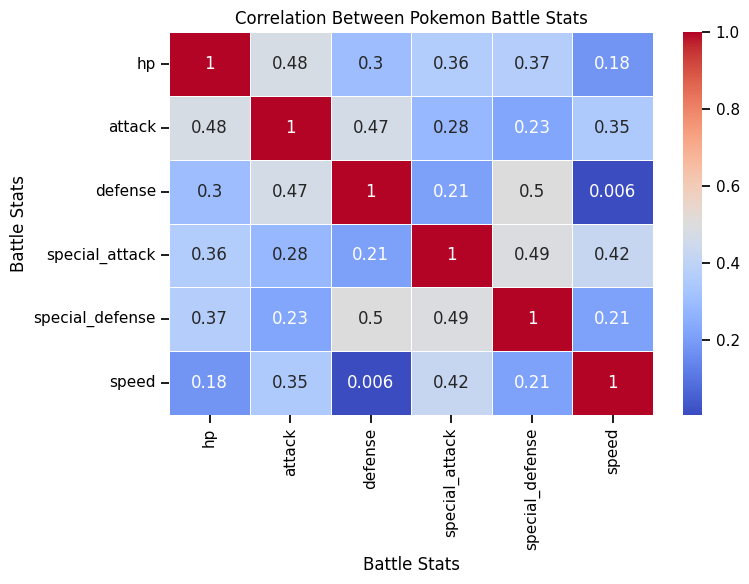

In [78]:
stats = ["hp","attack","defense","special_attack","special_defense","speed"]

plt.figure(figsize=(8,6))

sns.heatmap(
    df[stats].corr(),
    annot=True,
    cmap="coolwarm",
    linewidths=0.5
)

plt.title("Correlation Between Pokemon Battle Stats")
plt.xlabel("Battle Stats")
plt.ylabel("Battle Stats")

plt.tight_layout()
plt.savefig("images/correlation_heatmap.png")
plt.show()

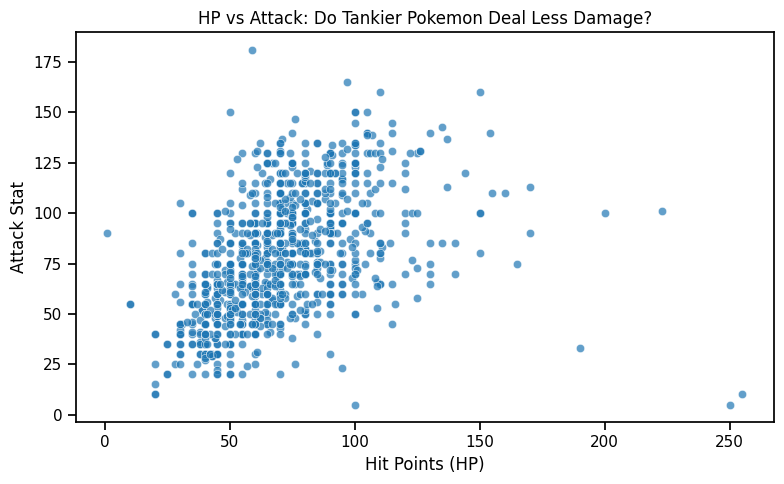

In [79]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=df,
    x="hp",
    y="attack",
    alpha=0.7
)

plt.title("HP vs Attack: Do Tankier Pokemon Deal Less Damage?")
plt.xlabel("Hit Points (HP)")
plt.ylabel("Attack Stat")

plt.tight_layout()
plt.savefig("images/hp_vs_attack.png")
plt.show()

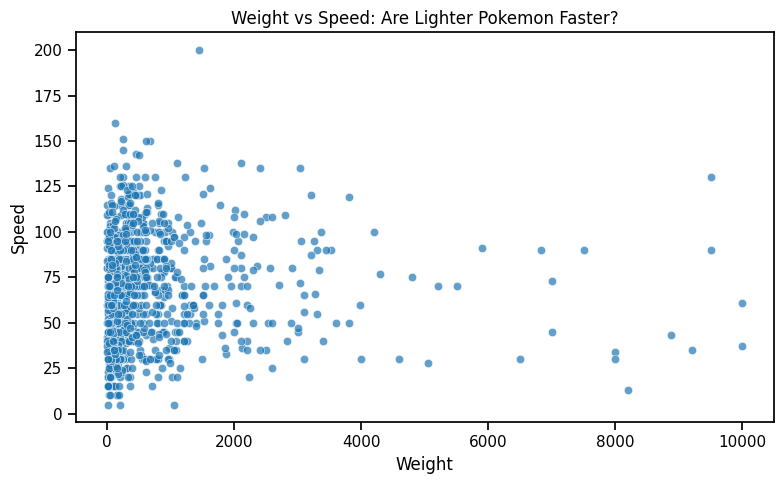

In [80]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=df,
    x="weight",
    y="speed",
    alpha=0.7
)

plt.title("Weight vs Speed: Are Lighter Pokemon Faster?")
plt.xlabel("Weight")
plt.ylabel("Speed")

plt.tight_layout()
plt.savefig("images/weight_vs_speed.png")
plt.show()

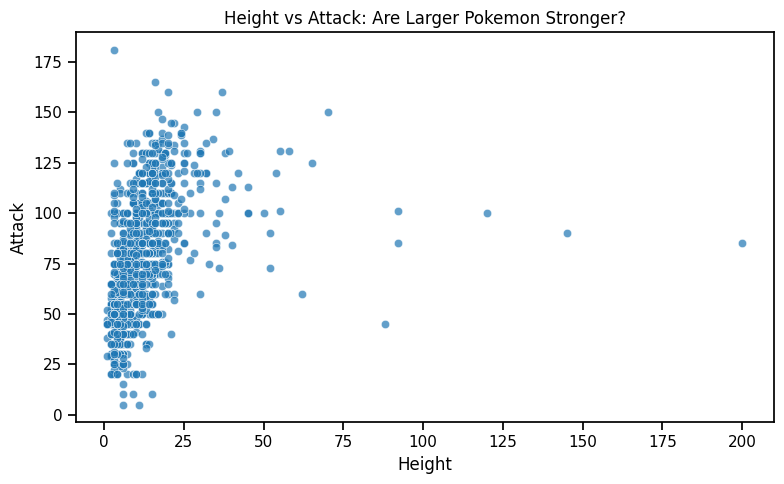

In [81]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=df,
    x="height",
    y="attack",
    alpha=0.7
)

plt.title("Height vs Attack: Are Larger Pokemon Stronger?")
plt.xlabel("Height")
plt.ylabel("Attack")

plt.tight_layout()
plt.savefig("images/height_vs_attack.png")
plt.show()

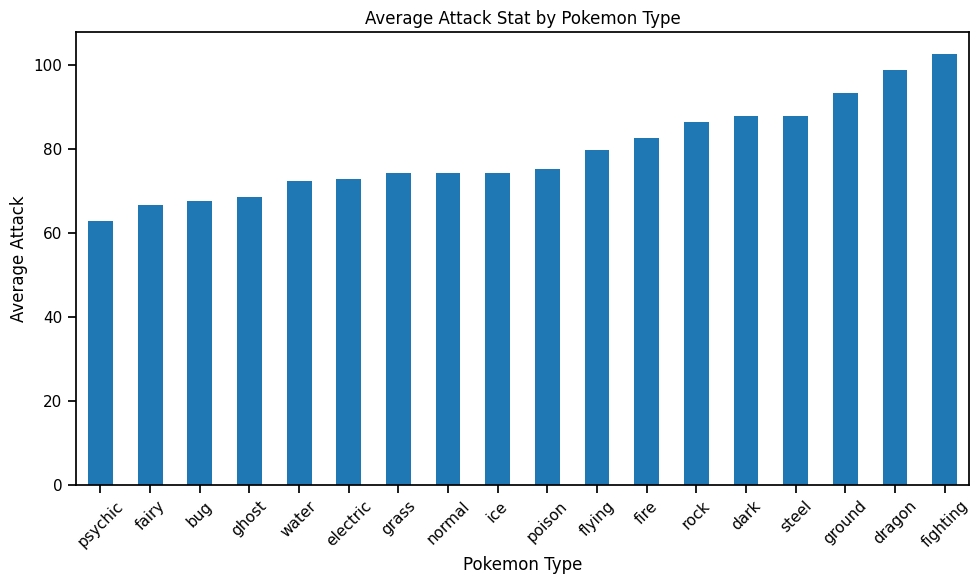

In [82]:
avg_attack = df.groupby("primary_type")["attack"].mean().sort_values()

plt.figure(figsize=(10,6))

avg_attack.plot(kind="bar")

plt.title("Average Attack Stat by Pokemon Type")
plt.xlabel("Pokemon Type")
plt.ylabel("Average Attack")

plt.xticks(rotation=45)

plt.tight_layout()
plt.savefig("images/avg_attack_by_type.png")
plt.show()

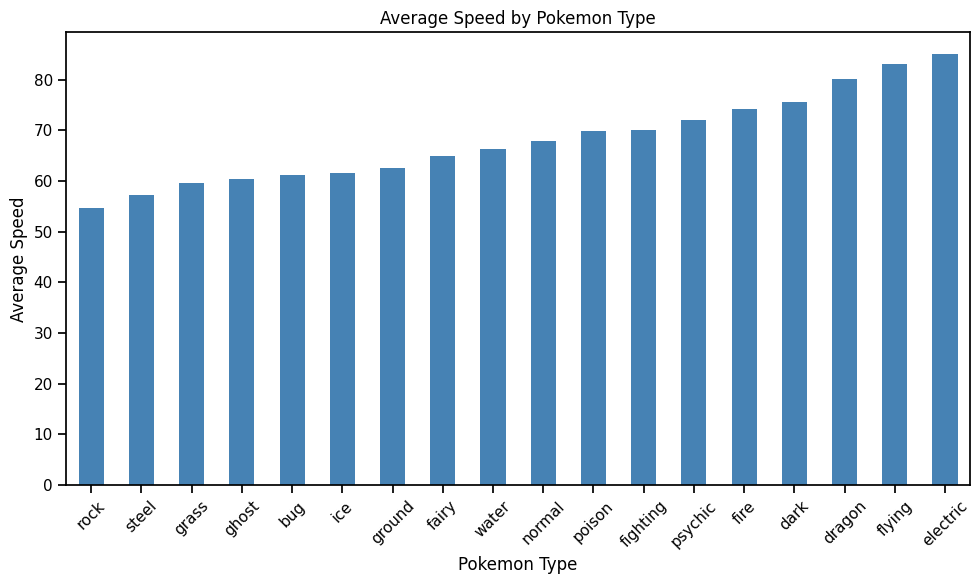

In [83]:
avg_speed = df.groupby("primary_type")["speed"].mean().sort_values()

plt.figure(figsize=(10,6))

avg_speed.plot(kind="bar", color="steelblue")

plt.title("Average Speed by Pokemon Type")
plt.xlabel("Pokemon Type")
plt.ylabel("Average Speed")

plt.xticks(rotation=45)

plt.tight_layout()
plt.savefig("images/avg_speed_by_type.png")
plt.show()

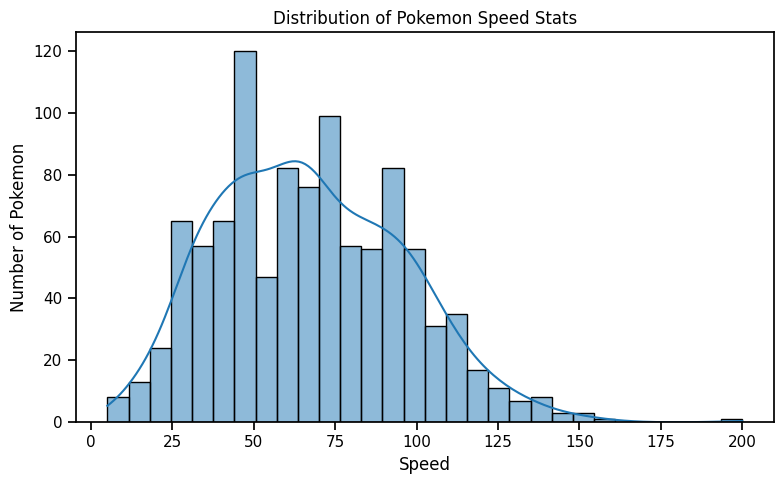

In [84]:
plt.figure(figsize=(8,5))

sns.histplot(df["speed"], bins=30, kde=True)

plt.title("Distribution of Pokemon Speed Stats")
plt.xlabel("Speed")
plt.ylabel("Number of Pokemon")

plt.tight_layout()
plt.savefig("images/speed_distribution.png")
plt.show()

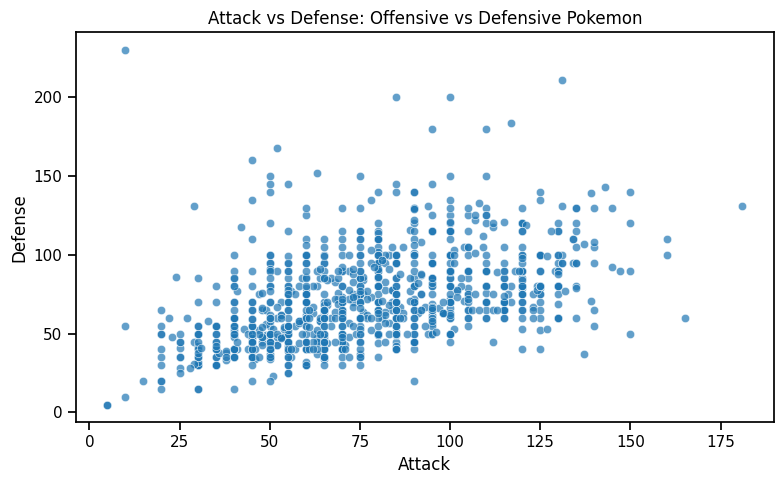

In [85]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=df,
    x="attack",
    y="defense",
    alpha=0.7
)

plt.title("Attack vs Defense: Offensive vs Defensive Pokemon")
plt.xlabel("Attack")
plt.ylabel("Defense")

plt.tight_layout()
plt.savefig("images/attack_vs_defense.png")
plt.show()

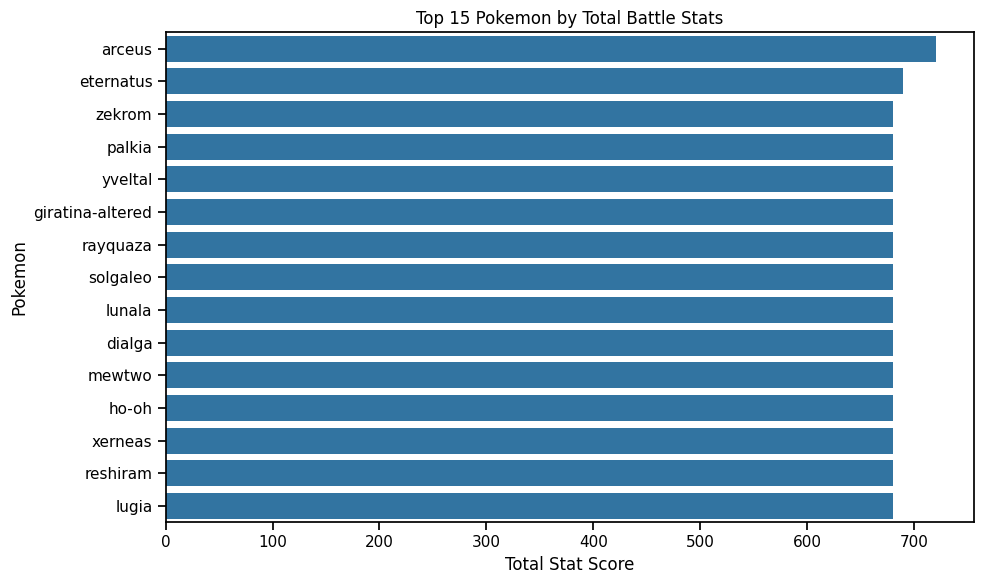

In [94]:
df["total_stats"] = (
    df["hp"]
    + df["attack"]
    + df["defense"]
    + df["special_attack"]
    + df["special_defense"]
    + df["speed"]
)

top = df.sort_values("total_stats", ascending=False).head(15)

plt.figure(figsize=(10,6))

sns.barplot(
    data=top,
    x="total_stats",
    y="name"
)

plt.title("Top 15 Pokemon by Total Battle Stats")
plt.xlabel("Total Stat Score")
plt.ylabel("Pokemon")

plt.tight_layout()
plt.savefig("images/top15_pokemon.png")
plt.show()

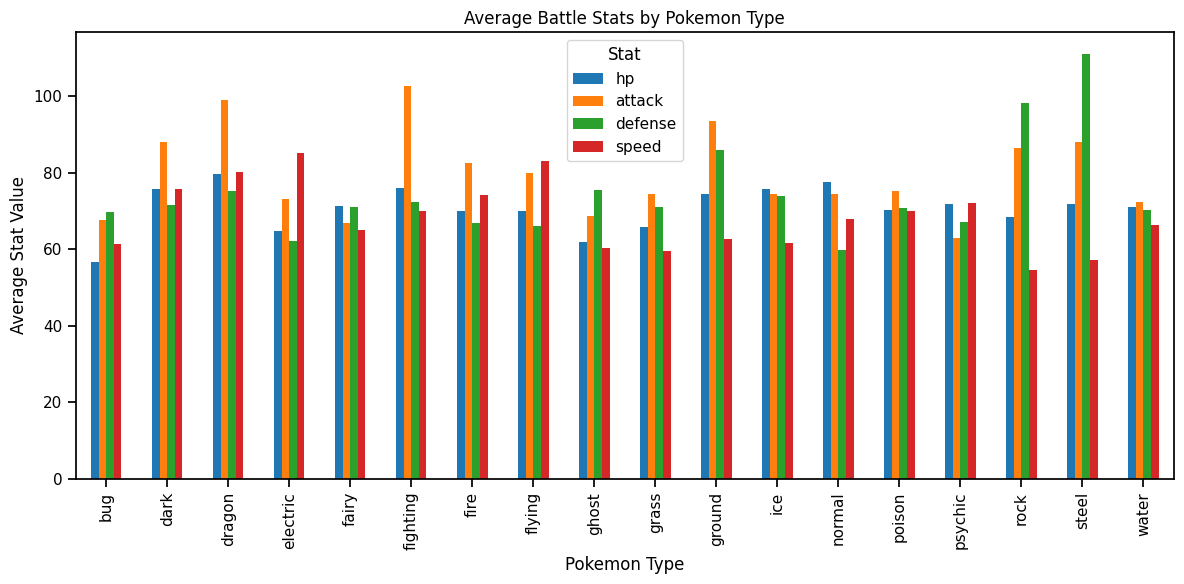

In [87]:
type_stats = df.groupby("primary_type")[["hp","attack","defense","speed"]].mean()

type_stats.plot(kind="bar", figsize=(12,6))

plt.title("Average Battle Stats by Pokemon Type")
plt.xlabel("Pokemon Type")
plt.ylabel("Average Stat Value")

plt.legend(title="Stat")

plt.tight_layout()
plt.savefig("images/stats_by_type.png")
plt.show()